# Housing Price Prediction using Maching Learning 

![image.png](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRHnqxV6ZfpbC_DESbyUdCvh4Bsm6WAAgs3Chs5uIqugw&s=10)

# Step 1 :- Load Important Modules 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import pickle


import os
import time
import warnings

warnings.filterwarnings('ignore')

print("All Modules Loaded Successfully !!")

All Modules Loaded Successfully !!


 # Step 2 :- Data Load

In [2]:
data = fetch_california_housing()

In [3]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

In [5]:
data.target_names

['MedHouseVal']

In [6]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
16559,3.6500,10.0,5.502092,1.060371,5935.0,3.547519,37.82,-121.28,1.194
6111,2.6619,25.0,4.090426,1.138298,2868.0,3.813830,34.13,-117.90,1.176
15133,2.3203,21.0,4.439446,0.961938,684.0,2.366782,32.83,-116.93,1.635
2542,1.8529,52.0,4.880878,1.078370,758.0,2.376176,40.80,-124.17,0.625
1963,4.0300,15.0,6.053371,1.106742,857.0,2.407303,38.77,-120.58,1.412


In [7]:
print(data['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

# Step 3:- Exploratory Data Analysis

In [8]:
rows, cols = df.shape
print('No of Rows :',rows)
print('No of Columns:',cols)

No of Rows : 20640
No of Columns: 9


In [9]:
df.sample()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
5075,2.3977,52.0,5.32345,1.021563,1043.0,2.811321,33.98,-118.31,1.122


In [10]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### No missing value in the dataset

In [14]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [15]:
len(df.columns)

9

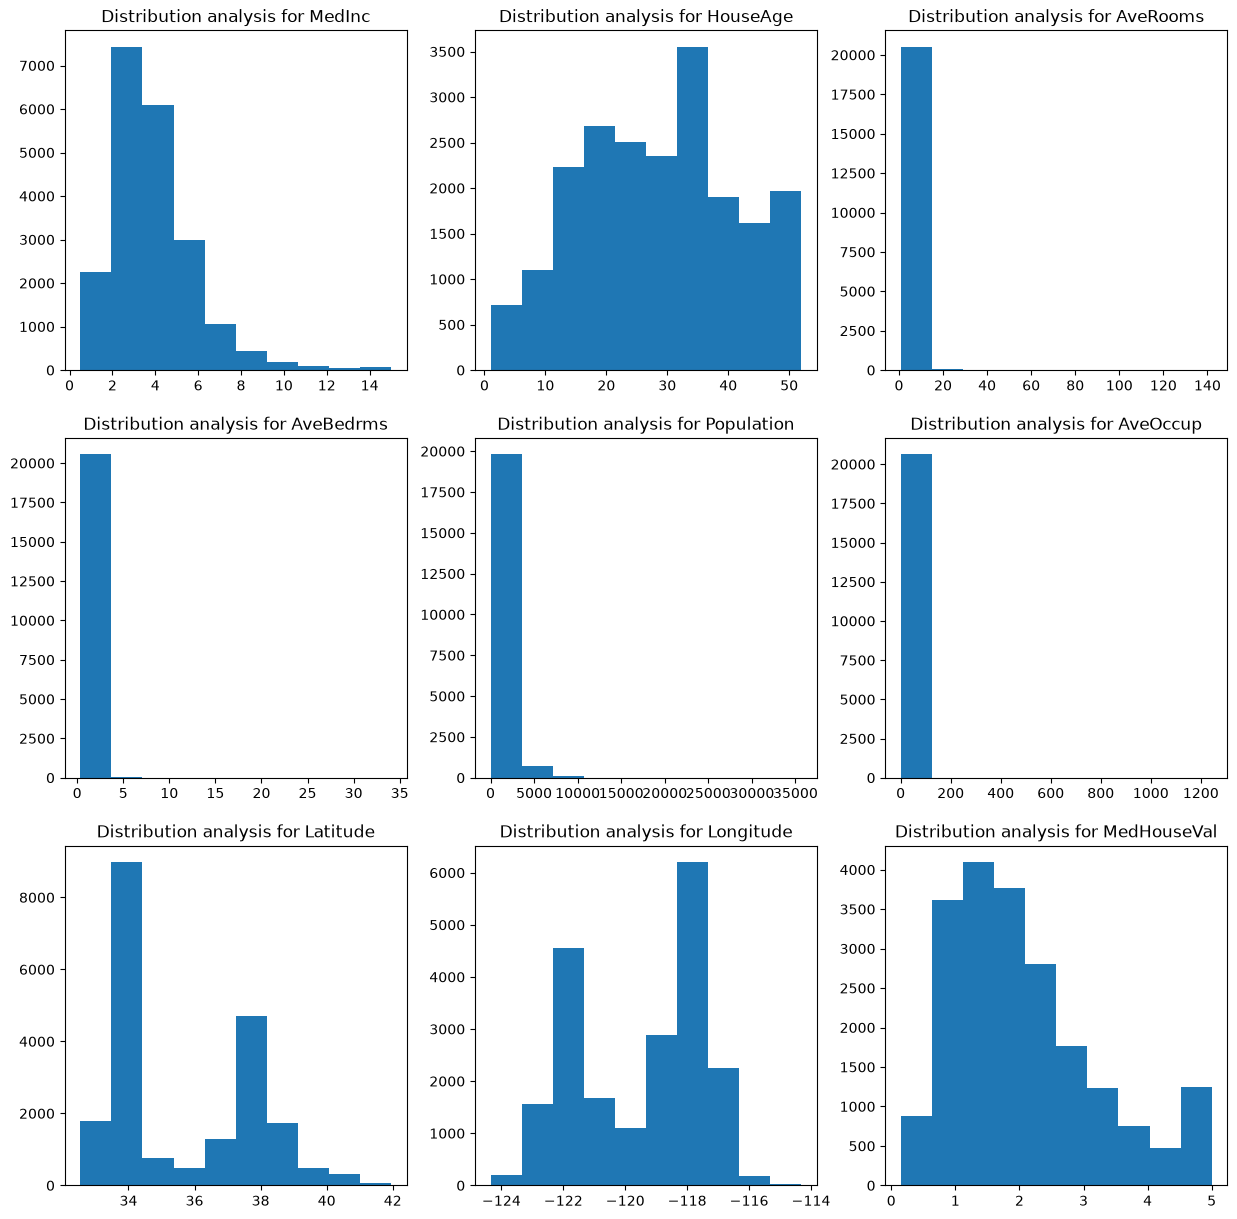

In [16]:
plt.figure(figsize=(15,15))

for i in range(len(df.columns)):
    plt.subplot(3, 3, i+1)
    plt.hist(df[df.columns[i]])
    plt.title(f'Distribution analysis for {df.columns[i]}')

plt.show()

In [17]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: title={'center': 'Correlation b/w Features'}>

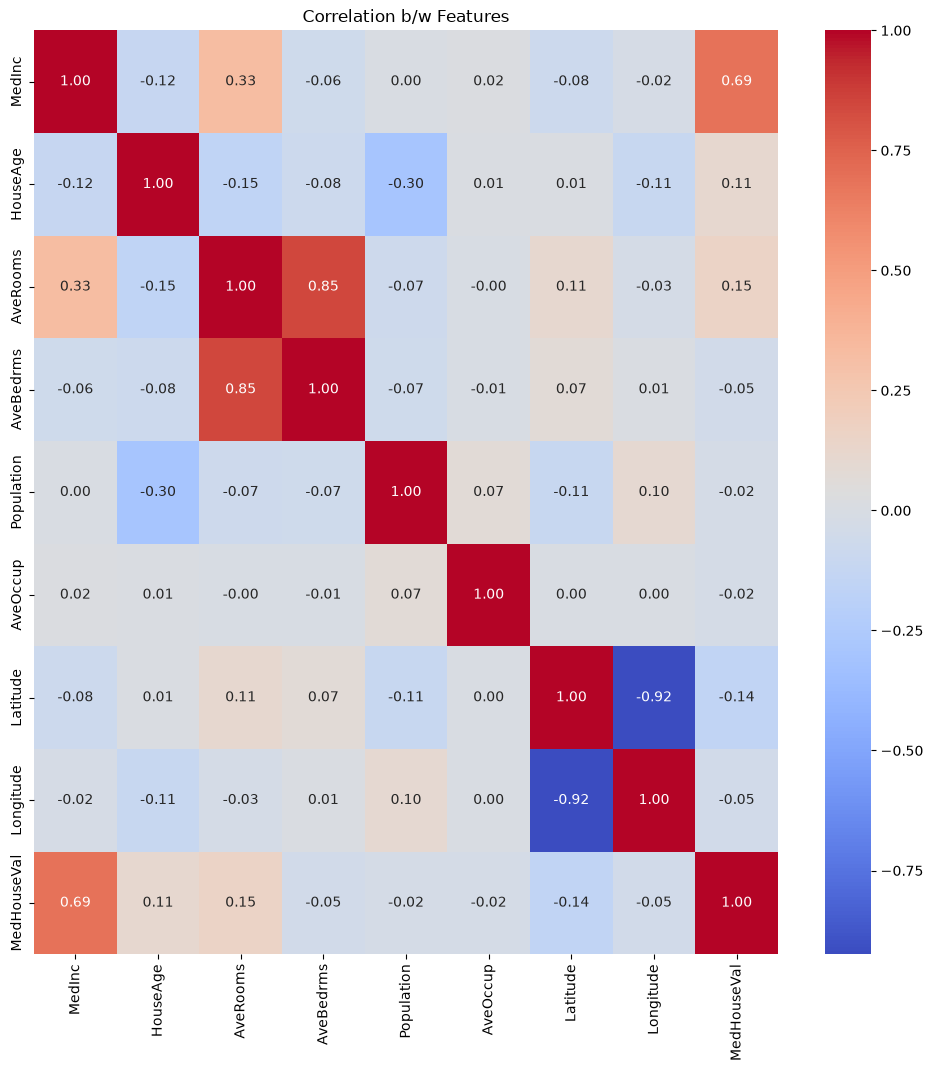

In [18]:
plt.figure(figsize=(12,12))
plt.title("Correlation b/w Features")
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f') 

# Step 4:- Data Preprocessing 

In [19]:
x = df.iloc[:,:-2]
x


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43


In [20]:
y = df['MedHouseVal']
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [21]:
# MIN_MAX_SCALER
# preprocessing our data and scaling it to a range of 0 to 1 using MinMaxScaler

In [22]:
scaler = MinMaxScaler()

In [23]:
scaled_x = scaler.fit_transform(x)

In [24]:
scaled_df = pd.DataFrame(scaled_x, columns=x.columns)
scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293


In [25]:
scaled_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,0.232464,0.541951,0.032488,0.022629,0.039869,0.001914,0.328572
std,0.131020,0.246776,0.017539,0.014049,0.031740,0.008358,0.226988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142308,0.333333,0.025482,0.019943,0.021974,0.001398,0.147715
50%,0.209301,0.549020,0.031071,0.021209,0.032596,0.001711,0.182784
75%,0.292641,0.705882,0.036907,0.022713,0.048264,0.002084,0.549416
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
scaled_df.shape

(20640, 7)

# Step 5 : Train Test part data divide


In [27]:
x_train, x_test, y_train, y_test = train_test_split(scaled_x, y, test_size=0.1,random_state=42)

In [28]:
x_train.shape

(18576, 7)

In [29]:
x_test.shape

(2064, 7)

In [30]:
y_train.shape

(18576,)

In [31]:
y_test.shape

(2064,)

# Step 6 :- Model Training

In [32]:
model = LinearRegression()

In [33]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 7.71, 0.85,-28.09,..., 0.58, -5.73, -0.29]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.0911
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[33.8 ,30.96,17.55,..., 2.9 , 1.19, 0.57]"


In [34]:
model.predict(x_test)

array([1.00271459, 1.5668127 , 2.56297224, ..., 2.35776269, 1.6409366 ,
       1.96947638], shape=(2064,))

In [35]:
y_pred = model.predict(x_test)

In [36]:
compare_df = pd.DataFrame({'Actual Y ': y_test, 'Predicted Y': y_pred})

In [37]:
compare_df

,Actual Y,Predicted Y
20046,0.47700,1.002715
3024,0.45800,1.566813
15663,5.00001,2.562972
20484,2.18600,2.693034
9814,2.78000,1.969685
...,...,...
9477,0.96000,1.675017
46,1.42500,1.676916
20462,2.66300,2.357763
4751,1.65000,1.640937


# Step 7 :- Model Evaluation 

In [38]:
score = model.score(x_test, y_test)
print("Model Score:", score)

Model Score: 0.5102156222486369


In [39]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.5895657614643507


In [40]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.6531810291705674


In [41]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.8081961576069063


# Step 8 :- Final Model checking

In [42]:
Matrix_dic = {
    'Model Number': [],
    'Model':[],
    'Model Score': [],
    'MAE': [],
    'MSE': [],
    'RMSE': []

}
    
for i in range(5000):
    x_train, x_test, y_train, y_test = train_test_split(scaled_x, y, test_size=0.1,random_state=i)
    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    score = model.score(x_test, y_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))


    Matrix_dic['Model Number'].append(i)
    Matrix_dic['Model'].append(model)
    Matrix_dic['Model Score'].append(score)
    Matrix_dic['MAE'].append(mae)
    Matrix_dic['MSE'].append(mse)
    Matrix_dic['RMSE'].append(rmse)
    print("checking Model",i+1)
    display(clear=True)

Matrix_df = pd.DataFrame(Matrix_dic)
print("Done")


Done


In [43]:
Matrix_df 

,Model Number,Model,Model Score,MAE,MSE,RMSE
0,0,LinearRegression(),0.539876,0.584250,0.632354,0.795207
1,1,LinearRegression(),0.539413,0.574266,0.619368,0.786999
2,2,LinearRegression(),0.502733,0.589630,0.668455,0.817591
3,3,LinearRegression(),0.568915,0.563485,0.580866,0.762146
4,4,LinearRegression(),0.533087,0.573290,0.587384,0.766410
...,...,...,...,...,...,...
4995,4995,LinearRegression(),0.500881,0.574729,0.642570,0.801605
4996,4996,LinearRegression(),0.500247,0.576966,0.693597,0.832825
4997,4997,LinearRegression(),0.505985,0.576654,0.662073,0.813678
4998,4998,LinearRegression(),0.517502,0.568705,0.611983,0.782293


In [44]:
Matrix_df['Model Score'].max()

np.float64(0.6053940148587416)

In [45]:
final_model_df = Matrix_df[Matrix_df['Model Score'] == Matrix_df['Model Score'].max()]

# Step 9: Final Model Save

In [46]:
final_model = final_model_df['Model']

In [47]:
with open('Chatgpt_for_house.pkl','wb')as f:
    pickle.dump(final_model,f)
print("Model Saved Successfully !!")

Model Saved Successfully !!


# Step 10:- Model Deployment on website

In [ ]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [2]:
import streamlit as st

streamlit run app.py
